In [217]:
graphics_toolkit("gnuplot");

In [218]:
function draw_trajectory(xB,yB,xG,yG,v_w,v_s,fig,tit)
    figure(fig); hold on; grid on; axis equal;
    fill([-2,12,12,-2,-2],[0,0,4,4,0],[0.7 0.9 1.0],'EdgeColor','none');
    fill([-2,12,12,-2,-2],[0,0,-4,-4,0],[1.0 0.9 0.7],'EdgeColor','none');
    plot([-2,12],[0,0],'k-','LineWidth',3);
    plot(xB,yB,'bo','MarkerSize',12,'MarkerFaceColor','b');
    plot(xG,yG,'ro','MarkerSize',12,'MarkerFaceColor','r');

    if (yB>0 && yG>0) || (yB<0 && yG<0)
        plot([xB,xG],[yB,yG],'r-','LineWidth',2);
        title(tit); 
    else
        T = @(x) sqrt((xB-x).^2+yB^2) / ((yB>0)*v_w + (yB<=0)*v_s) + ...
                 sqrt((xG-x).^2+yG^2) / ((yG>0)*v_w + (yG<=0)*v_s);
        a = min(xB,xG); b = max(xB,xG);
        x_opt = fminbnd(T,a,b);
        plot([xB,x_opt,xG],[yB,0,yG],'r-','LineWidth',2);
        plot(x_opt,0,'ko','MarkerFaceColor','y','MarkerSize',8);
        title(tit);  
        fprintf('%s: x_opt = %.6f, T(x_opt) = %.6f\n', tit, x_opt, T(x_opt));
    end
    xlabel('X'); ylabel('Y'); xlim([-2,12]); ylim([-4,4]);
end


Классика: x_opt = 0.689437, T(x_opt) = 5.289813


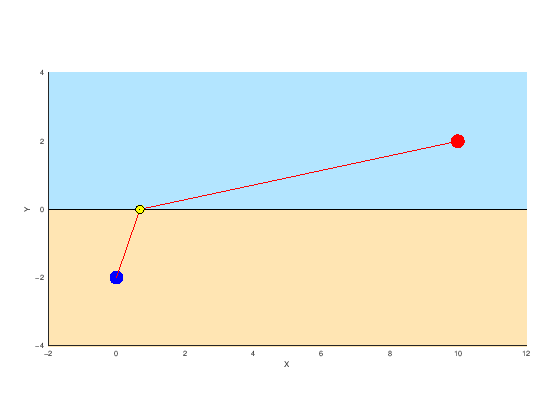

In [219]:
draw_trajectory(0, -2, 10, 2, 3.0, 1.0, 1, 'Классика');

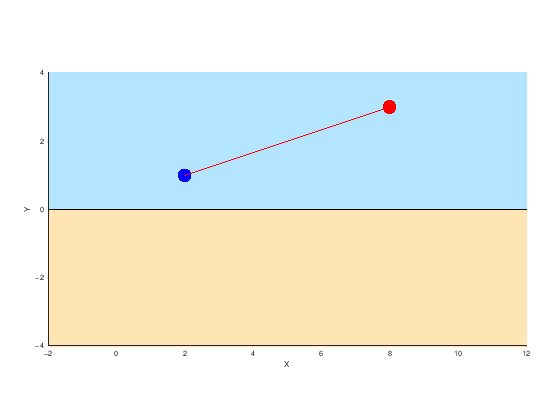

In [220]:
draw_trajectory(2, 1, 8, 3, 3.0, 1.0, 2, 'Обе в воде');

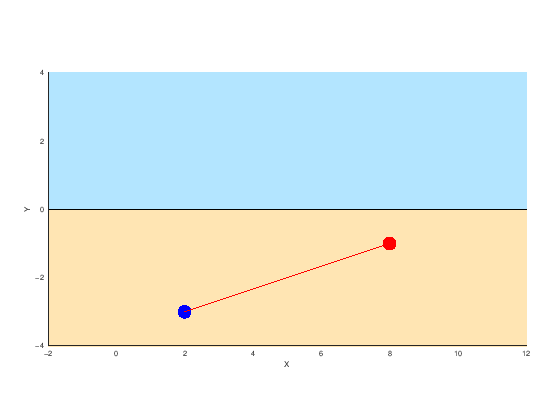

In [221]:
draw_trajectory(2, -3, 8, -1, 3.0, 1.0, 3, 'Обе в песке');


Равные скорости: x_opt = 5.000000, T(x_opt) = 5.385165


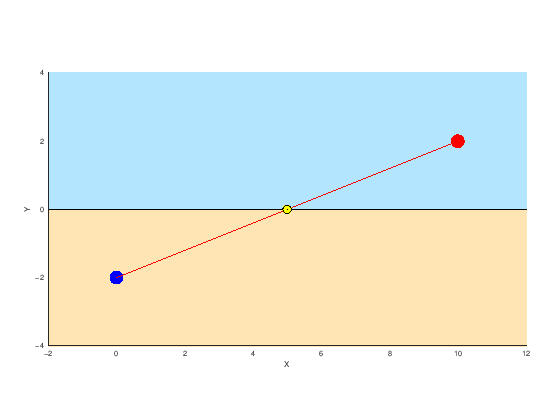

In [222]:
draw_trajectory(0, -2, 10, 2, 2.0, 2.0, 4, 'Равные скорости');


Вода быстрая: x_opt = 0.019611, T(x_opt) = 2.101884


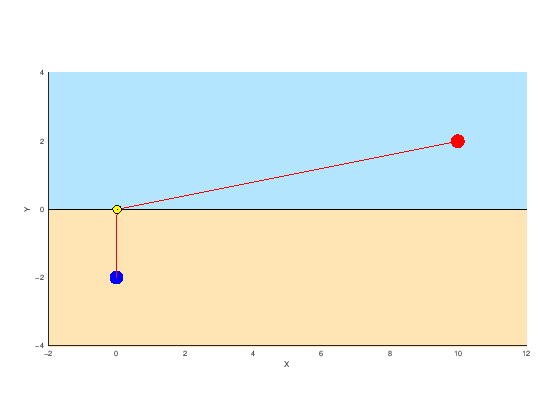

In [223]:
draw_trajectory(0, -2, 10, 2, 100.0, 1.0, 5, 'Вода быстрая');


Песок быстрый: x_opt = 9.980389, T(x_opt) = 2.101884


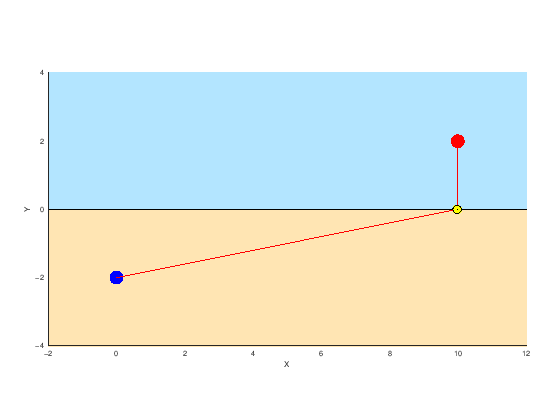

In [224]:
draw_trajectory(0, -2, 10, 2, 1.0, 100.0, 6, 'Песок быстрый');


На границе: x_opt = 0.000060, T(x_opt) = 3.399386


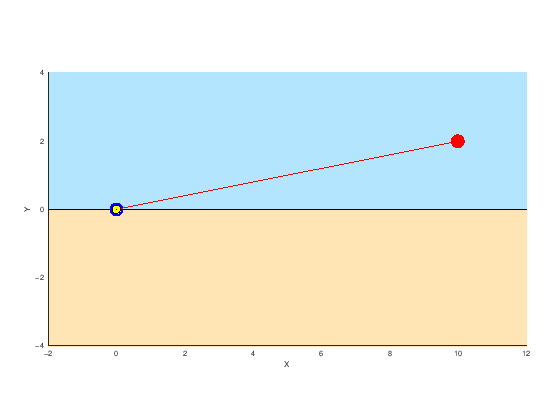

In [225]:
draw_trajectory(0, 0, 10, 2, 3.0, 1.0, 7, 'На границе');